# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ramithnayak8/ML_pipeline/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

Final score blends two validated pieces: the logistic regression from `w05_model.ipynb`/
`w06_validation_audit.ipynb` (the model that actually won on an honest client-holdout split),
and the transparent `rule_score` from `w04_baseline_score.ipynb` -- each converted to a
percentile rank first, then combined 60% model / 40% rule. The model is refit on ALL rows here:
validation already happened honestly in `w05`/`w06`, so this final artifact uses every available
row, the normal practice once a method is confirmed. Reason codes carry over the three from
`w04` plus a new one, `model_flagged_high_risk` (model probability >= 0.65), so a reviewer can
see whether a pick came from the readable rule, the model, or both.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

raw = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df = raw[(raw["impressions_90d"] > 0) & (raw["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)

df["has_keyword_data"] = df["search_volume"].notna().astype(int)
df["has_word_count"] = df["word_count"].notna().astype(int)
numeric_fill_zero = ["search_volume", "competition", "cpc", "word_count", "char_count",
                     "impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d",
                     "days_with_impressions", "days_with_sessions", "content_age_days",
                     "days_since_last_update", "ctr", "avg_position", "engagement_rate",
                     "scroll_rate", "ai_traffic_pct"]
for c in numeric_fill_zero:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan).fillna(0)
categorical_cols = ["competition_level", "content_type", "main_intent", "age_tier",
                    "freshness_tier", "word_count_tier", "impression_tier", "position_tier"]
for c in categorical_cols:
    df[c] = df[c].fillna("unknown").astype(str)
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

feature_cols = (["search_volume", "competition", "cpc", "word_count", "char_count",
                 "log_impressions_90d", "log_clicks_90d", "log_sessions_90d", "log_ai_sessions_90d",
                 "days_with_impressions", "days_with_sessions", "content_age_days",
                 "days_since_last_update", "ctr", "avg_position", "engagement_rate",
                 "scroll_rate", "ai_traffic_pct", "has_keyword_data", "has_word_count"]
                + categorical_cols)

stale_visible = (df["days_since_last_update"] >= 180) & (df["impressions_90d"] >= 500)
low_ctr_visible = ((df["impressions_90d"] >= 500) & (df["avg_position"] > 0)
                   & (df["avg_position"] <= 20) & (df["ctr"] < 0.5))
thin_visible = (df["word_count"] > 0) & (df["word_count"] < 1200) & (df["impressions_90d"] >= 250)
reason_count = stale_visible.astype(int) + low_ctr_visible.astype(int) + thin_visible.astype(int)
df["rule_score"] = reason_count + 0.99 * df["impressions_90d"].rank(pct=True)
df["rule_score_pct"] = df["rule_score"].rank(pct=True)

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df["is_declining_label"]
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
logit = LogisticRegression(max_iter=2000, random_state=42).fit(Xs, y)
df["model_proba"] = logit.predict_proba(Xs)[:, 1]
df["model_proba_pct"] = df["model_proba"].rank(pct=True)

df["final_score"] = 0.6 * df["model_proba_pct"] + 0.4 * df["rule_score_pct"]

def reason_codes(i):
    reasons = []
    if stale_visible[i]:
        reasons.append("stale_visible")
    if low_ctr_visible[i]:
        reasons.append("low_ctr_visible")
    if thin_visible[i]:
        reasons.append("thin_visible")
    if df.loc[i, "model_proba"] >= 0.65:
        reasons.append("model_flagged_high_risk")
    return "|".join(reasons) if reasons else "general_refresh_review"

df["reason_codes"] = [reason_codes(i) for i in df.index]

def suggested_action(reasons):
    r = set(reasons.split("|"))
    if "thin_visible" in r:
        return "expand_and_refresh"
    if "low_ctr_visible" in r:
        return "refresh_and_review_ctr"
    if "stale_visible" in r or "model_flagged_high_risk" in r:
        return "refresh"
    return "monitor"

df["suggested_action"] = df["reason_codes"].apply(suggested_action)

high_cut = df["final_score"].quantile(0.90)
def confidence(row):
    if (row["final_score"] >= high_cut and row["impressions_90d"] >= 500
            and row["reason_codes"] != "general_refresh_review"):
        return "high"
    if row["reason_codes"] != "general_refresh_review":
        return "medium"
    return "low"

df["confidence"] = df.apply(confidence, axis=1)
df["rank"] = df["final_score"].rank(method="first", ascending=False).astype(int)

print("confidence distribution:")
print(df["confidence"].value_counts())
print("\nsuggested action distribution:")
print(df["suggested_action"].value_counts())
print(f"\ntop-20 decline rate: {df.sort_values('rank').head(20)['is_declining_label'].mean():.1%}")


confidence distribution:
confidence
low       14844
medium    12160
high       2996
Name: count, dtype: int64

suggested action distribution:
suggested_action
monitor                   14844
refresh_and_review_ctr     9741
refresh                    5333
expand_and_refresh           82
Name: count, dtype: int64

top-20 decline rate: 75.0%


## 2. Intended use and limits

**Who uses this:** a content strategist or editor doing weekly refresh triage, working the top
of the queue down until their review capacity runs out.

**What it is for:** deciding WHICH pages to look at first -- a decision-support ranking, never
a verdict on any single page.

**Where it stops being valid:**
- The label is a proxy (`trend_direction`, a CURRENT-window bucket, not a future outcome --
  `w02_ml_task_framing.ipynb`), so this ranks "looks weak right now," not "will decline next
  month."
- Only ~10% of rows reach "high" confidence (below) -- most of the queue is a starting point for
  a human's judgment, not a strong signal on its own.
- Validated on ONE 30,000-row anonymized snapshot, 32 clients, one client-holdout split
  (`w05`/`w06`). Nothing here has been checked against the full warehouse or a second time
  period.
- Cannot distinguish real decline from consolidation or seasonality (no sibling-page or
  multi-period data in this slice -- lane guide, section 7).
- No causal claim: this never says a refresh WILL fix a page, only that it looks worth
  reviewing first.

In [2]:
print(f"rows in this queue: {len(df):,}")
print(f"clients represented: {df['client_id'].nunique()}")
conf_counts = df["confidence"].value_counts()
print(f"\nhigh-confidence share: {conf_counts['high']:,} of {len(df):,} rows "
      f"({conf_counts['high'] / len(df):.1%})")


rows in this queue: 30,000
clients represented: 32

high-confidence share: 2,996 of 30,000 rows (10.0%)


## 3. Human review + the no-go list

**Before acting on any pick, a person must check:**
- Is the flagged weakness (staleness / low CTR / thin content) still true today, or has the
  page already been touched since this snapshot?
- Does a related/sibling page on the same site show a matching GAIN -- a sign of consolidation,
  not decline (lane guide, section 7)?
- Is the page deliberately evergreen/reference content where "staleness" is a choice, not
  neglect?
- Is the pick concentrated in one client (checked below) -- a queue that is secretly "fix one
  client's site" is a different, undisclosed decision from "fix the worst pages across the
  portfolio."

**Never automate:**
- Never auto-publish or auto-edit content from this queue without a human reading the page.
- Never tell a client a page WILL improve if refreshed -- no causal design backs that.
- Never treat a `monitor` label as "safe" -- it means no reason code matched, not "confirmed
  healthy" (recall `w05`'s error analysis: real misses exist even among high-scored picks).

In [3]:
top50_clients = df.sort_values("rank").head(50)["client_id"].nunique()
top200_clients = df.sort_values("rank").head(200)["client_id"].nunique()
print(f"distinct clients in the top 50:  {top50_clients} (of {df['client_id'].nunique()} total)")
print(f"distinct clients in the top 200: {top200_clients}")
print("-> a human should check this isn't secretly a single-client list before acting on it.")


distinct clients in the top 50:  10 (of 32 total)
distinct clients in the top 200: 15
-> a human should check this isn't secretly a single-client list before acting on it.


## 4. Monitoring / retrain triggers

What would tell me these recommendations went stale:
- **Base rate drift.** This snapshot's decline rate is 54.2%. If a future batch's rate moves far
  from that (say, outside 45-65%), the content mix or the market has shifted enough that the
  model should be re-validated before trusting its ranking.
- **Precision drop.** `w05`/`w06` validated Precision@50 in the 0.64-0.72 range (honest
  client-holdout). If a later check (once real outcomes are observable) falls toward the
  baseline's 0.42, the model has stopped adding value and needs retraining.
- **Population-size drift.** The three reason-code populations below are this snapshot's
  reference point; large swings (e.g., `stale_visible` going from 17 rows to thousands) signal a
  changed content operation, not just noise.
- **A fixed cadence regardless.** Search behavior and site conditions drift even without an
  alarm -- re-validate at least quarterly on principle, not only when a trigger fires.

In [4]:
print(f"reference base rate: {df['is_declining_label'].mean():.1%}")
print(f"reference stale_visible count:   {stale_visible.sum()}")
print(f"reference low_ctr_visible count: {low_ctr_visible.sum()}")
print(f"reference thin_visible count:    {thin_visible.sum()}")
print("validated Precision@50 range (w05/w06, honest split): 0.64-0.72 vs baseline 0.42")


reference base rate: 54.2%
reference stale_visible count:   17
reference low_ctr_visible count: 9759
reference thin_visible count:    82
validated Precision@50 range (w05/w06, honest split): 0.64-0.72 vs baseline 0.42


## 5. Exports for the paper

Writing the full ranked queue to `work/outputs/action_playbook.csv`, and one comparison chart
(baseline vs logistic vs random forest, the `w05`/`w06` honest-split numbers) to
`work/outputs/charts/` for reuse in the capstone paper.

wrote ..\outputs\action_playbook.csv


wrote ..\outputs\charts\p50_comparison.png


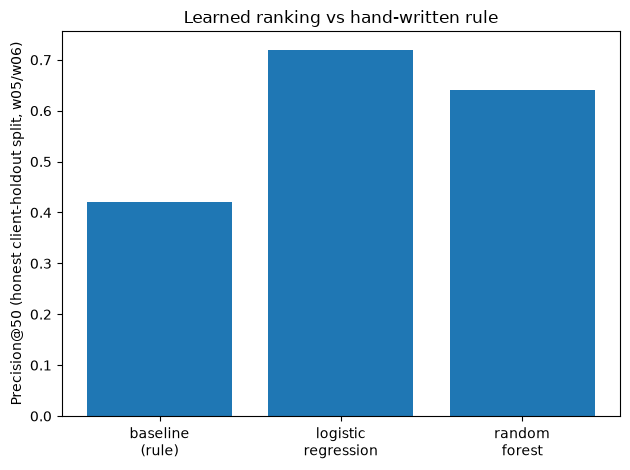

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path("../outputs")
chart_dir = out_dir / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

export_cols = ["content_id", "client_id", "rank", "final_score", "reason_codes",
               "suggested_action", "confidence", "is_declining_label", "impressions_90d",
               "avg_position", "ctr", "word_count", "days_since_last_update"]
df[export_cols].sort_values("rank").to_csv(out_dir / "action_playbook.csv", index=False)
print("wrote", out_dir / "action_playbook.csv")

fig, ax = plt.subplots()
names = ["baseline\n(rule)", "logistic\nregression", "random\nforest"]
p50 = [0.42, 0.72, 0.64]
ax.bar(names, p50)
ax.set_ylabel("Precision@50 (honest client-holdout split, w05/w06)")
ax.set_title("Learned ranking vs hand-written rule")
fig.tight_layout()
fig.savefig(chart_dir / "p50_comparison.png", dpi=120)
print("wrote", chart_dir / "p50_comparison.png")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.